# Relationship between income and private health insurance

The goal is to investigate the quantitative effect of income on the procurement of private health insurance using US census data. The target of inference is the logistic regression coefficient when regressing the binary indicator of health insurance on income. The data from California in the year 2019 is downloaded through the Folktables interface (1). Predictions of health insurance are made by training a gradient boosting tree via XGBoost (2) on the previous year’s data.

1. F. Ding, M. Hardt, J. Miller, L. Schmidt, “Retiring adult: New datasets for fair machine learning” in Advances in Neural Information Processing Systems 34 (2021), pp. 6478–6490.
2. T. Chen, C. Guestrin, “XGBoost: A scalable tree boosting system” in Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (2016), pp. 785–794.

### Import necessary packages

In [15]:
%load_ext autoreload
%autoreload 2
import os, sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
import numpy as np
import pandas as pd
from ppi_py.datasets import load_dataset
from ppi_py import ppi_logistic_ci, classical_logistic_ci, ppi_logistic_pointestimate
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from scipy.optimize import brentq
from utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import the census healthcare data set

Load the data. The data set contains reported indicators of health insurance (```Y```), predicted indicators of health insurance (```Yhat```), and reported income (```X```).

In [2]:
dataset_folder = "./data/"
data = load_dataset(dataset_folder, "census_healthcare")
Y_total = data["Y"]
Yhat_total = data["Yhat"]
X_total = data["X"]

### Problem setup

Specify the error level (```alpha```), range of values for the labeled data set size (```ns```), and number of trials (```num_trials```).

Compute the ground-truth value of the estimand.

In [3]:
alpha = 0.05
coordinate = 0  # Choose between 0, 1
n_total = Y_total.shape[0]  # Total number of labeled examples
ns = np.array([500, 1000, 2000]).astype(
    int
)  # Test for different numbers of labeled ballots
num_trials = 100
optimizer_options = {
    "ftol": 1e-5,
    "gtol": 1e-5,
    "maxls": 10000,
    "maxiter": 10000,
}
# Compute ground truth
true_theta = (
    LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=10000,
        tol=1e-15,
        fit_intercept=False,
    )
    .fit(X_total, Y_total)
    .coef_.squeeze()[coordinate]
)

### Construct intervals

Form confidence intervals for all methods and problem parameters. A dataframe with the following columns is formed:
1. ```method``` (one of ```PPI```, ```Classical```, and ```Imputation```)
2. ```n``` (labeled data set size, takes values in ```ns```)
3. ```lower``` (lower endpoint of the confidence interval)
4. ```upper``` (upper endpoint of the confidence interval)
5. ```trial``` (index of trial, goes from ```0``` to ```num_trials-1```)

In [6]:
# Run prediction-powered inference and classical inference for many values of n
results = []
for i in range(ns.shape[0]):
    for j in tqdm(range(num_trials)):
        # Prediction-Powered Inference
        n = ns[i]
        rand_idx = np.random.permutation(n_total)
        _X, _X_unlabeled = X_total[rand_idx[:n]], X_total[rand_idx[n:]]
        _Y, _Y_unlabeled = Y_total[rand_idx[:n]], Y_total[rand_idx[n:]]
        _Yhat, _Yhat_unlabeled = (
            Yhat_total[rand_idx[:n]],
            Yhat_total[rand_idx[n:]],
        )

        ppi_ci = ppi_logistic_ci(
            _X,
            _Y,
            _Yhat,
            _X_unlabeled,
            _Yhat_unlabeled,
            alpha=alpha,
            optimizer_options=optimizer_options,
        )

        # Classical interval
        classical_ci = classical_logistic_ci(_X, _Y, alpha=alpha)

        # Append results
        results += [
            pd.DataFrame(
                [
                    {
                        "method": "PPI",
                        "n": n,
                        "lower": ppi_ci[0][coordinate],
                        "upper": ppi_ci[1][coordinate],
                        "trial": j,
                    }
                ]
            )
        ]
        results += [
            pd.DataFrame(
                [
                    {
                        "method": "Classical",
                        "n": n,
                        "lower": classical_ci[0][coordinate],
                        "upper": classical_ci[1][coordinate],
                        "trial": j,
                    }
                ]
            )
        ]

# Imputed CI
imputed_ci = classical_logistic_ci(
    X_total, (Yhat_total > 0.5).astype(int), alpha=alpha
)
results += [
    pd.DataFrame(
        [
            {
                "method": "Imputation",
                "n": np.nan,
                "lower": imputed_ci[0][coordinate],
                "upper": imputed_ci[1][coordinate],
                "trial": 0,
            }
        ]
    )
]

df = pd.concat(results, axis=0, ignore_index=True)
df["width"] = df["upper"] - df["lower"]

100%|██████████| 100/100 [02:52<00:00,  1.73s/it]


### Plot results

Plot:
1. Five randomly chosen intervals from the dataframe for PPI and the classical method, and the imputed interval;
2. The average interval width for PPI and the classical method, together with a scatterplot of the widths from the five random draws.

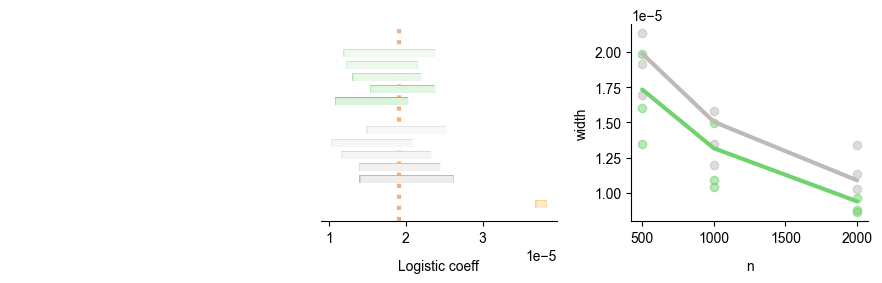

In [7]:
make_plots(
    df,
    "./plots/census_healthcare.pdf",
    intervals_xlabel="Logistic coeff",
    n_idx=-1,
    true_theta=true_theta,
)

### Power experiment

For PPI and the classical approach, find the smallest value of ```n``` such that the method has power 80% against the null $H_0: \theta^* < 0.5 \cdot 10^{-5}$.

In [8]:
# Find n such that we reject H0: Logistic coeff < 0.5*1e-5 with probability 80% using a test at level alpha
num_experiments = 100
list_rand_idx = [
    np.random.permutation(n_total) for i in range(num_experiments)
]


def _to_invert_ppi(n):
    # print(f"PPI: {n}")
    n = int(n)
    nulls_rejected = 0
    # Data setup
    for i in range(num_experiments):
        # print(f"PPI: {n}, {i}")
        rand_idx = list_rand_idx[i]
        _X, _X_unlabeled = X_total[rand_idx[:n]], X_total[rand_idx[n:]]
        _Y, _Y_unlabeled = Y_total[rand_idx[:n]], Y_total[rand_idx[n:]]
        _Yhat, _Yhat_unlabeled = (
            Yhat_total[rand_idx[:n]],
            Yhat_total[rand_idx[n:]],
        )

        ppi_ci = ppi_logistic_ci(
            _X,
            _Y,
            _Yhat,
            _X_unlabeled,
            _Yhat_unlabeled,
            alpha=alpha,
            optimizer_options=optimizer_options,
        )
        if ppi_ci[0][coordinate] > 1.5e-5:
            nulls_rejected += 1
    return nulls_rejected / num_experiments - 0.8


def _to_invert_classical(n):
    print(f"Classical: {n}")
    n = int(n)
    nulls_rejected = 0
    # Data setup
    for i in range(num_experiments):
        rand_idx = list_rand_idx[i]
        _X, _X_unlabeled = X_total[rand_idx[:n]], X_total[rand_idx[n:]]
        _Y, _Y_unlabeled = Y_total[rand_idx[:n]], Y_total[rand_idx[n:]]
        _Yhat, _Yhat_unlabeled = (
            Yhat_total[rand_idx[:n]],
            Yhat_total[rand_idx[n:]],
        )

        classical_ci = classical_logistic_ci(_X, _Y, alpha=alpha)
        if classical_ci[0][coordinate] > 1.5e-5:
            nulls_rejected += 1
    return nulls_rejected / num_experiments - 0.8

In [4]:
n_ppi = int(brentq(_to_invert_ppi, 150, 15000, xtol=100))
n_classical = int(brentq(_to_invert_classical, 150, 20000, xtol=100))
print(
    f"The PPI test requires n={n_ppi} labeled data points to reject the null."
)
print(
    f"The classical test requires n={n_classical} labeled data points to reject the null."
)

### Comparison with theoretical power analysis

In [6]:
n_max = Y_total.shape[0]
N_max = Yhat_total.shape[0]
from ppi_py import *

In [101]:
def _calc_lhat_glm(
    grads,
    grads_hat,
    grads_hat_unlabeled,
    inv_hessian,
    coord=None,
    clip=False,
    optim_mode="overall",
    ):
    """
    Calculates the optimal value of lhat for the prediction-powered confidence interval for GLMs.

    Args:
        grads (ndarray): Gradient of the loss function with respect to the parameter evaluated at the labeled data.
        grads_hat (ndarray): Gradient of the loss function with respect to the model parameter evaluated using predictions on the labeled data.
        grads_hat_unlabeled (ndarray): Gradient of the loss function with respect to the parameter evaluated using predictions on the unlabeled data.
        inv_hessian (ndarray): Inverse of the Hessian of the loss function with respect to the parameter.
        coord (int, optional): Coordinate for which to optimize `lhat`, when `optim_mode="overall"`.
        If `None`, it optimizes the total variance over all coordinates. Must be in {1, ..., d} where d is the shape of the estimand.
        clip (bool, optional): Whether to clip the value of lhat to be non-negative. Defaults to `False`.
        optim_mode (ndarray, optional): Mode for which to optimize `lhat`, either `overall` or `element`.
        If `overall`, it optimizes the total variance over all coordinates, and the function returns a scalar.
        If `element`, it optimizes the variance for each coordinate separately, and the function returns a vector.


    Returns:
        float: Optimal value of `lhat`. Lies in [0,1].
    """
    grads = reshape_to_2d(grads)
    grads_hat = reshape_to_2d(grads_hat)
    grads_hat_unlabeled = reshape_to_2d(grads_hat_unlabeled)
    n = grads.shape[0]
    N = grads_hat_unlabeled.shape[0]
    d = inv_hessian.shape[0]
    if grads.shape[1] != d:
        raise ValueError(
            "Dimension mismatch between the gradient and the inverse Hessian."
        )

    grads_cent = grads - grads.mean(axis=0)
    grad_hat_cent = grads_hat - grads_hat.mean(axis=0)
    cov_grads = (1 / n) * (
        grads_cent.T @ grad_hat_cent + grad_hat_cent.T @ grads_cent
    )

    var_grads_hat = np.cov(
        np.concatenate([grads_hat, grads_hat_unlabeled], axis=0).T
    )
    var_grads_hat = var_grads_hat.reshape(d, d)

    vhat = inv_hessian if coord is None else inv_hessian[coord, coord]
    if optim_mode == "overall":
        num = (
            np.trace(vhat @ cov_grads @ vhat)
            if coord is None
            else vhat @ cov_grads @ vhat
        )
        denom = (
            2 * (1 + (n / N)) * np.trace(vhat @ var_grads_hat @ vhat)
            if coord is None
            else 2 * (1 + (n / N)) * vhat @ var_grads_hat @ vhat
        )
        lhat = num / denom
        lhat = lhat.item()
    elif optim_mode == "element":
        num = np.diag(vhat @ cov_grads @ vhat)
        denom = 2 * (1 + (n / N)) * np.diag(vhat @ var_grads_hat @ vhat)
        lhat = num / denom
    else:
        raise ValueError(
            "Invalid value for optim_mode. Must be either 'overall' or 'element'."
        )
    if clip:
        lhat = np.clip(lhat, 0, 1)
    return lhat


In [9]:
def _logistic_get_stats(
    pointest,
    X,
    Y,
    Yhat,
    X_unlabeled,
    Yhat_unlabeled,
    w=None,
    w_unlabeled=None,
    use_unlabeled=True,
):
    """Computes the statistics needed for the logistic regression confidence interval.

    Args:
        pointest (ndarray): Point estimate of the logistic regression coefficients.
        X (ndarray): Covariates corresponding to the gold-standard labels.
        Y (ndarray): Gold-standard labels.
        Yhat (ndarray): Predictions corresponding to the gold-standard labels.
        X_unlabeled (ndarray): Covariates corresponding to the unlabeled data.
        Yhat_unlabeled (ndarray): Predictions corresponding to the unlabeled data.
        w (ndarray, optional): Standard errors of the gold-standard labels.
        w_unlabeled (ndarray, optional): Standard errors of the unlabeled data.
        use_unlabeled (bool, optional): Whether to use the unlabeled data.

    Returns:
        grads (ndarray): Gradient of the loss function on the labeled data.
        grads_hat (ndarray): Gradient of the loss function on the labeled predictions.
        grads_hat_unlabeled (ndarray): Gradient of the loss function on the unlabeled predictions.
        inv_hessian (ndarray): Inverse Hessian of the loss function on the unlabeled data.
    """
    n = Y.shape[0]
    d = X.shape[1]
    N = Yhat_unlabeled.shape[0]
    w = np.ones(n) if w is None else w / w.sum() * n
    w_unlabeled = (
        np.ones(N)
        if w_unlabeled is None
        else w_unlabeled / w_unlabeled.sum() * N
    )

    mu = safe_expit(X @ pointest)
    mu_til = safe_expit(X_unlabeled @ pointest)

    hessian = np.zeros((d, d))
    grads_hat_unlabeled = np.zeros(X_unlabeled.shape)
    if use_unlabeled:
        for i in range(N):
            hessian += (
                w_unlabeled[i]
                / (N + n)
                * mu_til[i]
                * (1 - mu_til[i])
                * np.outer(X_unlabeled[i], X_unlabeled[i])
            )
            grads_hat_unlabeled[i, :] = (
                w_unlabeled[i]
                * X_unlabeled[i, :]
                * (mu_til[i] - Yhat_unlabeled[i])
            )

    grads = np.zeros(X.shape)
    grads_hat = np.zeros(X.shape)
    for i in range(n):
        hessian += (
            w[i] / (N + n) * mu[i] * (1 - mu[i]) * np.outer(X[i], X[i])
            if use_unlabeled
            else w[i] / n * mu[i] * (1 - mu[i]) * np.outer(X[i], X[i])
        )
        grads[i, :] = w[i] * X[i, :] * (mu[i] - Y[i])
        grads_hat[i, :] = w[i] * X[i, :] * (mu[i] - Yhat[i])

    inv_hessian = np.linalg.inv(hessian).reshape(d, d)
    return grads, grads_hat, grads_hat_unlabeled, inv_hessian

In [187]:
pointestimate = true_theta = (
    LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=10000,
        tol=1e-15,
        fit_intercept=False,
    )
    .fit(X_total, Y_total)
    .coef_.squeeze())

grads, grads_hat, grads_hat_unlabeled, inv_hessian = _logistic_get_stats(pointestimate, 
                                                                         X_total, 
                                                                         Y_total, 
                                                                         Yhat_total, 
                                                                         X_total, 
                                                                         Yhat_total,
                                                                         use_unlabeled=False)

In [188]:
grads_ = grads - np.mean(grads, axis=0)
grads_hat_ = grads_hat - np.mean(grads_hat, axis=0)
rho_sq = (inv_hessian @ grads_.T @ grads_hat_ @ inv_hessian)[coordinate, coordinate]**2
rho_sq /= (inv_hessian @ grads_.T @ grads_ @ inv_hessian)[coordinate, coordinate] * (inv_hessian @ grads_hat_.T @ grads_hat_ @ inv_hessian)[coordinate, coordinate]
print(f"Rho^2: {rho_sq}")

sigma_sq = (inv_hessian @ grads_.T @ grads_ @ inv_hessian)[coordinate, coordinate]/grads_.shape[0]
print(f"Sigma^2: {sigma_sq}")

Rho^2: 0.28578156569861796
Sigma^2: 1.5781739506605666e-08


In [189]:

def compute_SE(n, N, rho_sq, sigma_sq):
    var_ppi = sigma_sq/n * (1-N*rho_sq/(n+N))
    return np.sqrt(var_ppi)

def estimate_SE(n, 
                n_max, 
                N, 
                N_max, 
                Y, 
                Yhat,
                X, 
                Yhat_unlabeled,
                X_unlabeled, 
                coordinate = coordinate):
    rand_idx = np.random.permutation(n_max)
    _Yhat = Yhat[rand_idx[:n]]
    _Y = Y[rand_idx[:n]]
    _X = X[rand_idx[:n],:]

    rand_idx = np.random.permutation(N_max)
    _Yhat_unlabeled = Yhat_unlabeled[rand_idx[:N]]
    _X_unlabeled = X_unlabeled[rand_idx[:N],:]

    ppi_ci = ppi_logistic_ci(_X, _Y, _Yhat, _X_unlabeled, _Yhat_unlabeled, alpha=0.05, optimizer_options=optimizer_options)

    return (ppi_ci[1][coordinate]-ppi_ci[0][coordinate])/(2*1.96)

In [290]:
ns = np.array([500, 1000, 2000])
n_max = ns.max()
rand_idx = np.random.permutation(Y_total.shape[0])
Y = Y_total[rand_idx[:n_max]]
X = X_total[rand_idx[:n_max], :]
print(X.shape)
Yhat = Yhat_total[rand_idx[:n_max]]

Yhat_unlabeled = Yhat_total[rand_idx[n_max:]]
X_unlabeled = X_total[rand_idx[n_max:],:]
print(X_unlabeled.shape)

N_max = Yhat_unlabeled.shape[0]

(2000, 2)
(316215, 2)


In [291]:
estimate_SE(1000, n_max, 1000, N_max, Y, Yhat, X, Yhat_unlabeled, X_unlabeled)

3.7422716454006975e-06

In [292]:
Ns = np.array([500, 1000, 2000, 5000, 10000])
num_trials = 100
theoretical_SEs = np.zeros((ns.shape[0], Ns.shape[0]))
empirical_SEs = np.zeros((ns.shape[0], Ns.shape[0], num_trials))
for i in range(ns.shape[0]):
    for j in range(Ns.shape[0]):
        theoretical_SEs[i,j] = compute_SE(ns[i], Ns[j],  rho_sq, sigma_sq)
        for k in tqdm(range(num_trials)):
            empirical_SEs[i,j,k] = estimate_SE(ns[i], n_max, Ns[j], N_max, Y, Yhat, X, Yhat_unlabeled, X_unlabeled)

100%|██████████| 100/100 [00:08<00:00, 11.50it/s]


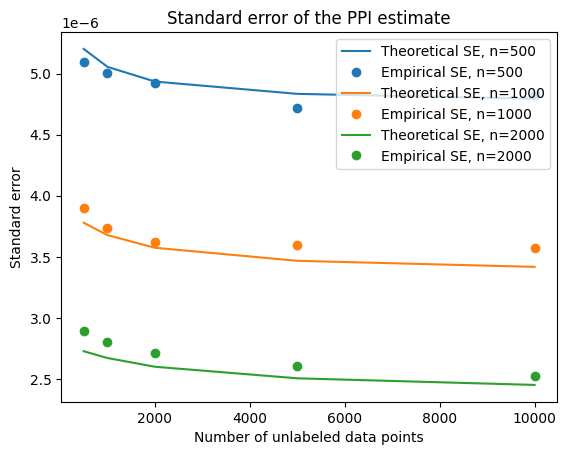

In [293]:
for i in range(ns.shape[0]):
    color = next(plt.gca()._get_lines.prop_cycler)['color']
    plt.plot(Ns, theoretical_SEs[i,:], label=f"Theoretical SE, n={ns[i]}", color=color)
    plt.plot(Ns, empirical_SEs[i,:,:].mean(axis = 1), 'o', label=f"Empirical SE, n={ns[i]}", color=color)


plt.legend()
plt.xlabel("Number of unlabeled data points")
plt.ylabel("Standard error")
plt.title("Standard error of the PPI estimate")
plt.show()

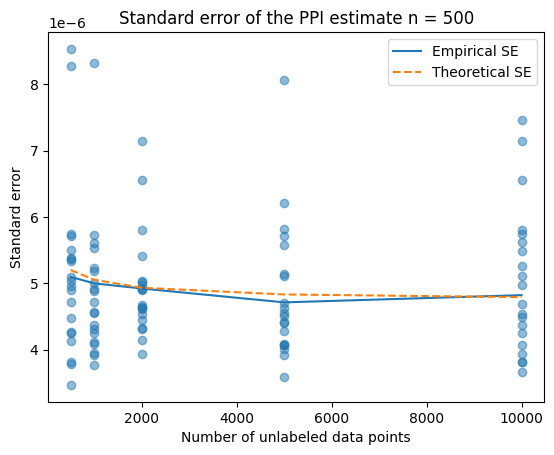

In [302]:
Ns_ = np.zeros_like(empirical_SEs[0,:,:20])
Ns_ += Ns[:,None]
plt.scatter(Ns_, empirical_SEs[0,:,:20], alpha=0.5)
plt.xlabel("Number of unlabeled data points")
plt.plot(Ns, empirical_SEs[0,:,].mean(axis=1), label="Empirical SE")
plt.plot(Ns, theoretical_SEs[0,:], '--', label="Theoretical SE")
plt.ylabel("Standard error")
plt.legend()
plt.title(f"Standard error of the PPI estimate n = {ns[0]}")
plt.show()

In [269]:
n = 2000
N = 1000
k = N/n

rand_idx = np.random.permutation(n_max)
_Yhat = Yhat[rand_idx[:n]]
_Y = Y[rand_idx[:n]]
_X = X[rand_idx[:n],:]
rand_idx = np.random.permutation(N_max)
_Yhat_unlabeled = Yhat_unlabeled[rand_idx[:N]]
_X_unlabeled = X_unlabeled[rand_idx[:N],:]

grads, grads_hat, grads_hat_unlabeled, inv_hessian = _logistic_get_stats(pointestimate, _X, _Y, _Yhat, _X_unlabeled, _Yhat_unlabeled, use_unlabeled=True)
grads_ = grads - np.mean(grads, axis=0)
grads_hat_ = grads_hat - np.mean(grads_hat, axis=0)
grads_hat_cov = np.cov(np.concatenate([grads_hat, grads_hat_unlabeled], axis=0).T)
lambda_star = k/(1+k)*(inv_hessian @ grads_.T @ grads_hat_ @ inv_hessian)[coordinate, coordinate]/n 
lambda_star /= (inv_hessian @ grads_hat_cov @ inv_hessian)[coordinate, coordinate]
print(f"Lambda*: {lambda_star}")
l_hat = _calc_lhat_glm(grads, grads_hat, grads_hat_unlabeled, inv_hessian, clip=False, optim_mode="element")[coordinate]
print(f"Lhat: {l_hat}")

rho = ((inv_hessian @ grads_.T @ grads_hat_ @ inv_hessian)[coordinate, coordinate]/n)**2

rho_0 = rho /((inv_hessian @ grads_.T @ grads_/n @ inv_hessian)[coordinate, coordinate] * (inv_hessian @ grads_hat_cov @ inv_hessian)[coordinate, coordinate])
rho_1 = rho / ((inv_hessian @ grads_.T @ grads_/n @ inv_hessian)[coordinate, coordinate] * (inv_hessian @ grads_hat_.T @ grads_hat_ /n@ inv_hessian)[coordinate, coordinate])
print(f"Rho0_sq: {rho_0}")
print(f"Rho1_sq: {rho_1}")
print(f"Rho^2: {rho_sq}")


Lambda*: 0.28109608196548796
Lhat: 0.28109608196548813
Rho0_sq: 0.29150317065838666
Rho1_sq: 0.2336730865587431
Rho^2: 0.28578156569861796


In [270]:
print((inv_hessian @ grads_hat_cov @ inv_hessian))
print((inv_hessian @ np.cov(grads_hat.T) @ inv_hessian))

[[ 1.01069491e-08 -3.04834660e-09]
 [-3.04834660e-09  1.16190844e-09]]
[[ 1.26145531e-08 -3.76168834e-09]
 [-3.76168834e-09  1.36526560e-09]]


In [272]:
print(grads_hat_cov)
print(np.cov(grads_hat.T))
print(np.cov(grads.T))

[[4.54125239e+08 2.23286118e+08]
 [2.23286118e+08 7.73778869e+08]]
[[5.58904814e+08 2.37240789e+08]
 [2.37240789e+08 7.76908733e+08]]
[[1.21124383e+09 7.03390893e+08]
 [7.03390893e+08 1.79906545e+09]]


In [ ]:
grads_hat_

In [121]:
np.cov(np.concatenate([grads_hat, grads_hat_unlabeled], axis=0).T)

array([[1.85951895e+08, 1.84647231e+08],
       [1.84647231e+08, 7.80436379e+08]])

In [122]:
np.cov(grads_hat.T)

array([[2.41278029e+08, 1.90737130e+08],
       [1.90737130e+08, 7.66265497e+08]])